In [1]:
# Necessary packages to run this file:
import spectral
import spectral.io.envi as envi
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import matplotlib.image as img
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
path = '/n/archive/labs/hsi-data/everyday_objects/kitchen/'

folder_name1 = 'basmatiriisi'
file_number1 = '040'

folder_name2 = 'kuivahiiva'
file_number2 = '042'

folder_name3 = 'seesaminsiemen'
file_number3 = '044'

folder_name4 = "rikottu_ohrasuurimo"
file_number4 = "036"

h = envi.read_envi_header(path+folder_name1+'/capture/'+file_number1+'.hdr')['wavelength']
k = []
for i in h:
    k.append(float(i))

In [4]:
image = envi.open(path+folder_name1+'/capture/'+file_number1+'.hdr')
data = image.load()

wavelengths = image.metadata.get('wavelength', None)
if wavelengths:
    [float(w) for w in wavelengths]

In [3]:
def retrieve_picture(path, folder_name, file_number):
    data = envi.open(path+folder_name+'/capture/'+file_number)
    data_white = envi.open(path+folder_name+'/capture/WHITEREF_'+file_number)
    data_dark = envi.open(path+folder_name+'/capture/DARKREF_'+file_number)
    return data, data_white, data_dark

def references(path, folder_name, file_number):
    dark_ref = envi.open(path+folder_name+'/capture/DARKREF_'+file_number+'.hdr', path+folder_name+'/capture/DARKREF_'+file_number+'.raw')
    white_ref = envi.open(path+folder_name+'/capture/WHITEREF_'+file_number+'.hdr', path+folder_name+'/capture/WHITEREF_'+file_number+'.raw')
    data_ref = envi.open(path+folder_name+'/capture/'+file_number+'.hdr', path+folder_name+'/capture/'+file_number+'.raw')
    return data_ref, white_ref, dark_ref

def toArray(path, folder_name, file_number):
    data_ref, white_ref, dark_ref = references(path, folder_name, file_number)

    white_arr = np.array(white_ref.load())
    dark_arr = np.array(dark_ref.load())
    data_arr = np.array(data_ref.load())

    corrected_arr = np.divide(
    np.subtract(data_arr, dark_arr),
    np.subtract(white_arr, dark_arr))
    return corrected_arr

def squeeze(x, y, path, folder_name, file_number):
    corrected_arr = toArray(path, folder_name, file_number)

    pixel = corrected_arr[
    y:y+1,
    x:x+1,
    :]

    return np.squeeze(pixel)

ImageView object:
  Display bands       :  (100, 100, 100)
  Interpolation       :  <default>
  RGB data limits     :
    R: [np.float64(0.02631578966975212), np.float64(0.9361382126808167)]
    G: [np.float64(0.02631578966975212), np.float64(0.9361382126808167)]
    B: [np.float64(0.02631578966975212), np.float64(0.9361382126808167)]

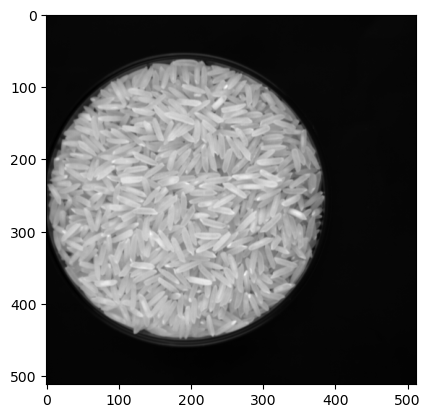

In [4]:
spectral.imshow(toArray(path, folder_name1, file_number1), (100, 100, 100))

# Pikselit voisi valita väliltä [150:350, 100:300]

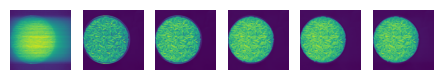

In [21]:
data_raw = spectral.envi.open('/n/archive/labs/hsi-data/everyday_objects/kitchen/basmatiriisi/capture/040.hdr')

cube_raw = np.array(data_raw.asarray())

i = 6

for p in range(0, i):
    plt.subplot(1, i+1, p+1)
    plt.imshow(cube_raw[:,:,int(p*(204/i))])
    plt.axis('off')

plt.show()

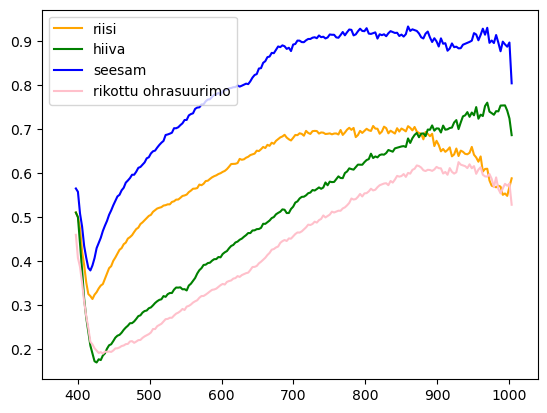

In [38]:
graphs = []

x = np.random.randint(150, 350)
y = np.random.randint(100, 300)

# Basmatiriisi
graphs.append(squeeze(x, y, path, folder_name1, file_number1))
#squeeze(200, 301, path, folder_name1, file_number1)
# Kuivahiiva
graphs.append(squeeze(x, y, path, folder_name2, file_number2))
#squeeze(200, 301, path, folder_name2, file_number2)
# Seesaminsiemen
graphs.append(squeeze(x, y, path, folder_name3, file_number3))
#squeeze(200, 301, path, folder_name3, file_number3)
graphs.append(squeeze(x, y, path, folder_name4, file_number4))

plt.plot(k, graphs[0], label = 'riisi', color='orange')
plt.plot(k, graphs[1], label = 'hiiva', color='green')
plt.plot(k, graphs[2], label = 'seesam', color='blue')
plt.plot(k, graphs[3], label = "rikottu ohrasuurimo", color = "pink")
plt.legend(loc='upper left')
plt.xlim(350,1040)
plt.show()

[ 262  262  264  266  270  276  284  299  312  331  352  370  394  415
  435  453  472  485  503  516  531  546  566  586  605  625  644  662
  678  695  708  723  743  757  784  797  819  831  847  864  873  890
  904  912  925  941  954  963  978  986 1006 1010 1026 1034 1053 1061
 1072 1087 1095 1108 1123 1133 1142 1149 1151 1166 1167 1172 1176 1176
 1178 1187 1180 1197 1194 1193 1190 1195 1195 1188 1187 1180 1181 1180
 1179 1167 1158 1160 1141 1145 1136 1127 1119 1107 1103 1101 1092 1087
 1072 1060 1038 1025 1006  997  994  974  966  951  947  935  925  910
  902  886  870  852  841  828  817  800  792  779  761  748  737  727
  717  710  692  685  669  658  643  636  628  614  605  598  591  583
  572  562  552  545  539  533  525  519  511  506  499  494  486  479
  476  469  462  457  450  450  441  435  426  423  416  410  404  399
  392  388  379  375  368  364  359  354  353  350  345  342  339  335
  332  327  324  318  315  311  307  302  298  295  291  288  285  282
  279 

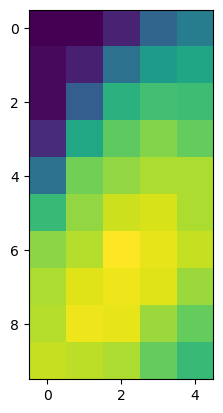

In [43]:
print(cube_raw[200,200])
plt.imshow(cube_raw[200:210,200:205,10])
plt.show()

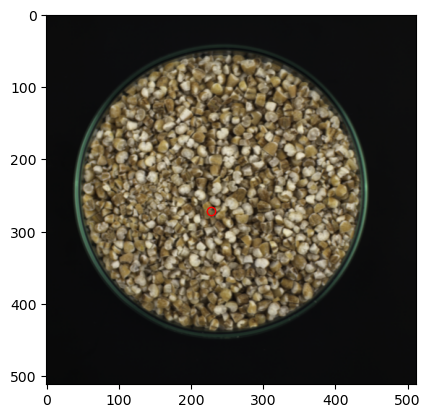

In [9]:
image = img.imread('/n/archive/labs/hsi-data/everyday_objects/kitchen/rikottu_ohrasuurimo/036.png')
plt.plot(x, y, marker="o", color="red", fillstyle = "none")
plt.imshow(image)

[0.4836563  0.42525265 0.30846548 1.        ]
[0.4836563  0.42525265 0.30846548 1.        ]


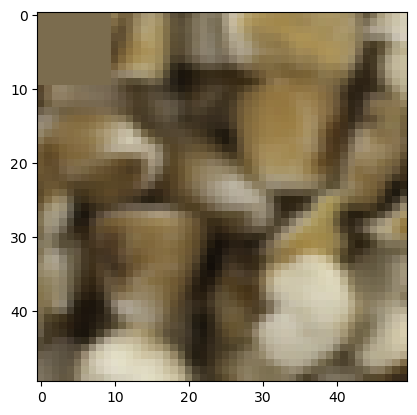

In [20]:
cropped = image[200:250, 200:250]
print(np.average(cropped, axis = (0,1)))
print(np.mean(cropped, axis = (0,1)))
cropped[:10,:10] = [0.4836563,  0.42525265, 0.30846548, 1.        ]
plt.imshow(cropped)

In [ ]:
pixels = []
means = []

for i in range(0, 20):
    x = np.random.randint(150, 350)
    y = np.random.randint(100, 300)
    pixels.append(squeeze(x, y, path, folder_name4, file_number4))



[np.float32(0.87414503), np.float32(0.3977127), np.float32(0.66952336), np.float32(0.517577), np.float32(0.7066257), np.float32(0.5045841), np.float32(0.81971484), np.float32(0.61820453), np.float32(0.5173532), np.float32(0.6036101), np.float32(0.47920838), np.float32(0.68502164), np.float32(0.65594864), np.float32(0.7551516), np.float32(0.62873334), np.float32(0.38613623), np.float32(0.46016926), np.float32(0.5921783), np.float32(0.44303992), np.float32(0.61419946)]


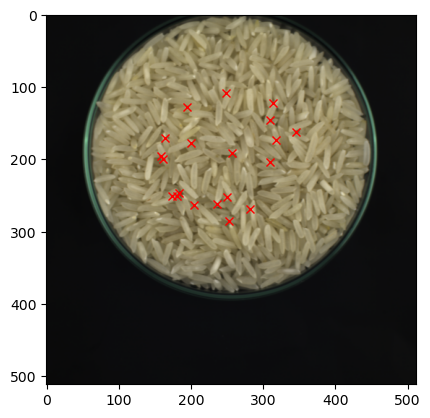

In [10]:
pixels = []
categories = []
coords = [[],[]]

for i in range(0, 20):
    x = np.random.randint(150, 350)
    y = np.random.randint(100, 300)
    pixels.append(squeeze(x, y, path, folder_name1, file_number1))
    categories.append("riisi")
    coords[0].append(x)
    coords[1].append(y)

for i in range(0, 20):
    pixels.append(squeeze(np.random.randint(150, 350), np.random.randint(100, 300), path, folder_name2, file_number2))
    categories.append("hiiva")

for i in range(0, 20):
    pixels.append(squeeze(np.random.randint(150, 350), np.random.randint(100, 300), path, folder_name3, file_number3))
    categories.append("seesam")

for i in range(0, 20):
    plt.plot(coords[0][i], coords[1][i], marker="x", color="red")

plt.imshow(image)

In [9]:
df = pd.DataFrame(pixels)
s = pd.Series(categories)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    df, s, test_size=0.25, random_state=42
)

In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [13]:
y_pred = model.predict(X_test)
y_pred
accuracy = accuracy_score(y_test, y_pred)
print(f"accuracy: {round(accuracy,2)}")

accuracy: 0.93
